# <b>Eleventh Stage: Thermodynamic Analysis</b>

In [1]:
%matplotlib inline
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from equilibrator_pathway import Pathway, ThermodynamicModel
from equilibrator_api.model import Bounds
from equilibrator_api import ComponentContribution, Q_
from sbtab import SBtab

In [2]:
# set up ComponentContribution object to calculate dG values
cc = ComponentContribution()

In [3]:
file_name = '../Datasets/Hyd_MDF.tsv'
sbtab_file = open(file_name, 'r')
file_content = sbtab_file.read()
sbtab_file.close()


Sd = SBtab.SBtabDocument()
Sd.set_filename(file_name)
Sd.set_name('My_SBtab_Document')
Sd.add_sbtab_string(file_content, file_name)

for t in Sd.sbtabs:
    print(t.table_name)
    display(t.to_data_frame())

Configuration


,Option,Value,Comment
0,p_h,7.5 dimensionless,
1,p_mg,3.0 dimensionless,
2,ionic_strength,0.25 molar,
3,temperature,298.15 kelvin,
4,algorithm,MDF,
5,stdev_factor,1.96,


Reaction


,ID,ReactionFormula
0,HK,ATP + D_Glucose = ADP + D_Glucose_6_phosphate
1,PGI,D_Glucose_6_phosphate = Beta_D_Fructose_6_phos...
2,PFK,ATP + Beta_D_Fructose_6_phosphate = ADP + Beta...
3,FBA,Beta_D_Fructose_16_bisphosphate = Dihydroxyace...
4,TPI,Dihydroxyacetone_phosphate = Glyceraldehyde_3_...
5,GAPD,Glyceraldehyde_3_phosphate + Nicotinamide_aden...
6,PGK,13_Biphosphoglycerate + ADP = 3_Phospho_D_glyc...
7,PGM,3_Phospho_D_glycerate = D_Glycerate_2_phosphate
8,ENO,D_Glycerate_2_phosphate = H2O + Phosphoenolpyr...
9,PYK,ADP + Phosphoenolpyruvate = ATP + Pyruvate


Compound


...

,QuantityType,Reaction,Compound,Value,Unit
0,reaction gibbs energy,HK,,-20.40,kJ/mol
1,reaction gibbs energy,PGI,,6.99,kJ/mol
2,reaction gibbs energy,PFK,,-21.05,kJ/mol
3,reaction gibbs energy,FBA,,22.05,kJ/mol
4,reaction gibbs energy,TPI,,5.62,kJ/mol
5,reaction gibbs energy,GAPD,,-1.83,kJ/mol
6,reaction gibbs energy,PGK,,-16.56,kJ/mol
7,reaction gibbs energy,PGM,,4.47,kJ/mol
8,reaction gibbs energy,ENO,,-3.81,kJ/mol
9,reaction gibbs energy,PYK,,-25.03,kJ/mol


ConcentrationConstraint


,QuantityType,Compound,Min,Max
0,concentration,H2O,1e+03,1e+03
1,concentration,ATP,5,5
2,concentration,ADP,0.5,0.5
3,concentration,Nicotinamide_adenine_dinucleotide,1,1
4,concentration,Phosphate,10,10
5,concentration,Nicotinamide_adenine_dinucleotide_reduced,0.1,0.1
6,concentration,Coenzyme_A,1,1
7,concentration,CO2,0.01,0.01
8,concentration,Acetyl_CoA,0.001,10
9,concentration,Pyruvate,0.001,10


Flux


,QuantityType,Reaction,Value
0,rate of reaction,HK,3
1,rate of reaction,PGI,3
2,rate of reaction,PFK,3
3,rate of reaction,FBA,3
4,rate of reaction,TPI,3
5,rate of reaction,GAPD,6
6,rate of reaction,PGK,6
7,rate of reaction,PGM,6
8,rate of reaction,ENO,6
9,rate of reaction,PYK,6


In [4]:
pp_pfor = ThermodynamicModel.from_sbtab('../Datasets/Hyd_MDF.tsv')
pp_pfor.update_standard_dgs()

display (pp_pfor.net_reaction_formula)

'6 ADP + 4 Coenzyme_A + 3 D_Glucose + 6 Phosphate + 2 Pyruvate = 2 2_hydroxypropanoate + 6 ATP + 4 Acetyl_CoA + 4 CO2 + 2 Ethanol + 2 Formate + 4 H2 + 6 H2O'

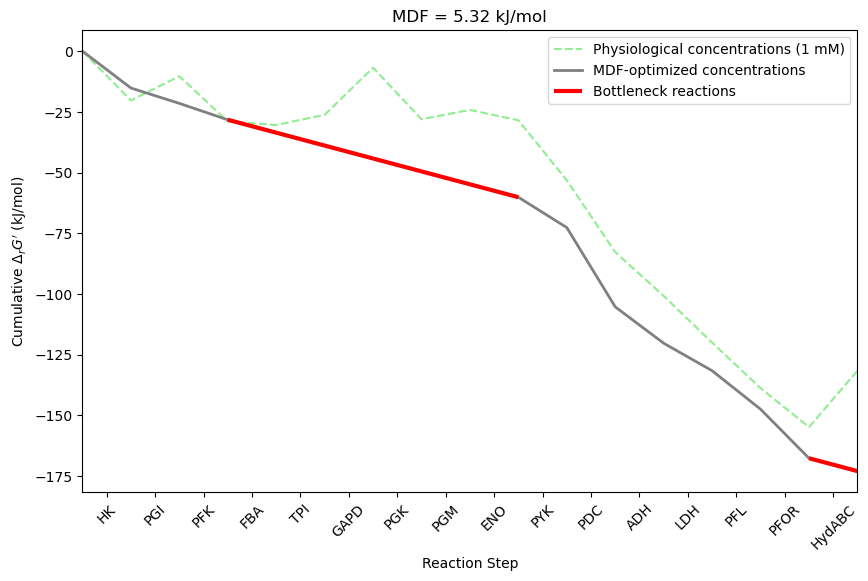

In [6]:
mdf_result_pfor = pp_pfor.mdf_analysis()
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
mdf_result_pfor.plot_driving_forces(ax=ax)

plt.savefig('../Images/MDF_Normal.png',dpi=1200)

In [9]:
def max_concentration(pp):
    concentration = 0
    
    while True:
        pp.set_bounds('H2', Q_(concentration, 'mM'), Q_(concentration, 'mM'))
        result = pp.mdf_analysis().score
        
        if 0 > result:
            concentration -= 0.01
            pp.set_bounds('H2', Q_(concentration, 'mM'), Q_(concentration, 'mM'))
            result = pp.mdf_analysis().score
            
            return (concentration,result)
        
        else:
            concentration += 0.01

In [10]:
result = max_concentration(pp_pfor)

print(f'Maximum concentration of H2 produced: {result[0]} mM')
print(f"MDF value: {result[1]} kj/mol")

Maximum concentration of H2 produced: 4.279999999999953 mM
MDF value: 0.010977294593770275 kj/mol


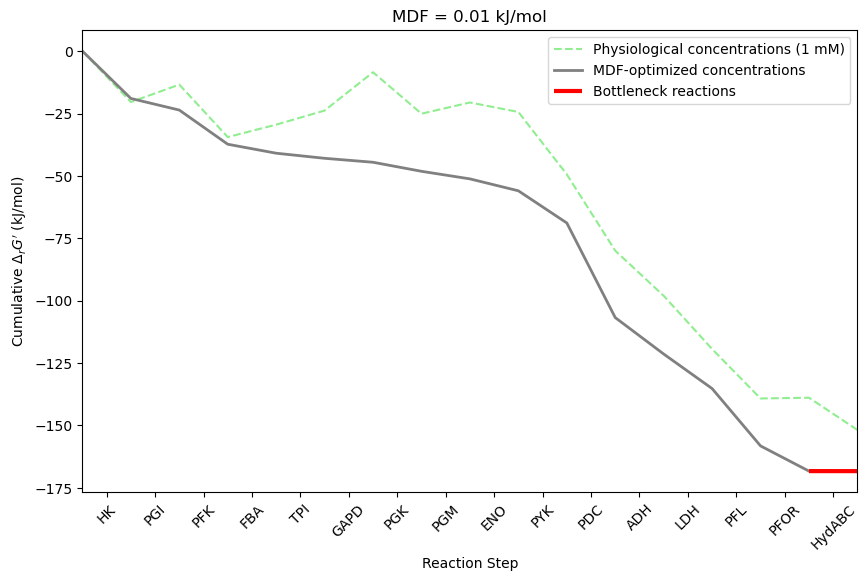

In [12]:
pp_pfor.set_bounds('H2', Q_(4.28, 'mM'), Q_(4.28, 'mM'))
mdf_result_pfor = pp_pfor.mdf_analysis()
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
mdf_result_pfor.plot_driving_forces(ax=ax)

plt.savefig('../Images/MDF_Max.png',dpi=1200)

## <b>End of Part 11! </b>